# Ablation - No PSG, No CAD (concatenated input)
Heatmap concatenated as an additional image channel (in_channels=2), plain decoder without prompt-conditioned attention.

**Run sequentially: Setup -> (%%writefile if present) -> Config -> Test -> Visualization**

In [1]:
import os, sys, shutil
import gdown

BASE = '/content'
os.chdir(BASE)

REPO = 'https://github.com/ThongLuc2k3/PGA_Unet2D.git'
REPO_ROOT = f'{BASE}/PGA_Unet2D'
PGA_ROOT = f'{REPO_ROOT}/Source/Prompt-Guided-XRay-Segmentation'
DATASET_NAME = 'dataset_BTXRD'
DATASET_ID = '1Ep3w8GujpCQ5Qb6nlXKxXhsCxlc3k8gx'
DS_ZIP = f'{BASE}/{DATASET_NAME}.zip'
DS_PATH = f'{PGA_ROOT}/{DATASET_NAME}'

if os.path.exists(REPO_ROOT):
    shutil.rmtree(REPO_ROOT)
!git clone -q {REPO} {REPO_ROOT}
if PGA_ROOT not in sys.path:
    sys.path.insert(0, PGA_ROOT)

if not os.path.exists(DS_ZIP):
    gdown.download(f'https://drive.google.com/uc?id={DATASET_ID}', DS_ZIP, quiet=False)
if os.path.exists(DS_PATH):
    shutil.rmtree(DS_PATH)
!unzip -oq {DS_ZIP} -d {PGA_ROOT}/

os.makedirs(f'{PGA_ROOT}/checkpoints', exist_ok=True)
!pip install -q tqdm opencv-python timm scipy matplotlib gdown
print(f'✅ Setup completed | base={BASE} | dataset={DATASET_NAME}')

# Checkpoint: fill in before running.
CKPT_ID = '1zUwPQy1UU8kSnv_dfRlPFeZ44GeXw3Ww'
CKPT_PATH = f'{PGA_ROOT}/checkpoints/best.pth'
os.makedirs(os.path.dirname(CKPT_PATH), exist_ok=True)
assert CKPT_ID, '❌ CKPT_ID is missing - upload the ablation checkpoint to Drive and fill in the ID here'
gdown.download(f'https://drive.google.com/uc?id={CKPT_ID}', CKPT_PATH, quiet=False)
assert os.path.exists(CKPT_PATH)
print(f'✅ Checkpoint ready: {CKPT_PATH}')


Downloading...
From (original): https://drive.google.com/uc?id=1Ep3w8GujpCQ5Qb6nlXKxXhsCxlc3k8gx
From (redirected): https://drive.google.com/uc?id=1Ep3w8GujpCQ5Qb6nlXKxXhsCxlc3k8gx&confirm=t&uuid=02054d30-ce49-4209-831c-ef5cbeb181bc
To: /content/dataset_BTXRD.zip
100%|██████████| 1.71G/1.71G [00:13<00:00, 124MB/s]


✅ Setup completed | base=/content | dataset=dataset_BTXRD


Downloading...
From: https://drive.google.com/uc?id=1zUwPQy1UU8kSnv_dfRlPFeZ44GeXw3Ww
To: /content/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/checkpoints/best.pth
100%|██████████| 9.91M/9.91M [00:00<00:00, 119MB/s]

✅ Checkpoint ready: /content/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/checkpoints/best.pth


In [2]:
%%writefile /content/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/models/networks/prompt_unet_2D.py
import torch
import torch.nn as nn
import torch.nn.functional as F


class unetConv2(nn.Module):
    def __init__(self, in_size, out_size, is_batchnorm=True):
        super().__init__()
        if is_batchnorm:
            self.conv = nn.Sequential(
                nn.Conv2d(in_size, out_size, 3, 1, 1), nn.BatchNorm2d(out_size), nn.ReLU(inplace=True),
                nn.Conv2d(out_size, out_size, 3, 1, 1), nn.BatchNorm2d(out_size), nn.ReLU(inplace=True))
        else:
            self.conv = nn.Sequential(
                nn.Conv2d(in_size, out_size, 3, 1, 1), nn.ReLU(inplace=True),
                nn.Conv2d(out_size, out_size, 3, 1, 1), nn.ReLU(inplace=True))
    def forward(self, x): return self.conv(x)


class unetUp_Standard(nn.Module):
    def __init__(self, skip_ch, gate_ch, out_ch):
        super().__init__()
        self.up   = nn.ConvTranspose2d(gate_ch, skip_ch, kernel_size=4, stride=2, padding=1)
        self.conv = unetConv2(skip_ch * 2, out_ch)
    def forward(self, skip, gating):
        u = self.up(gating)
        dy, dx = u.size(2)-skip.size(2), u.size(3)-skip.size(3)
        skip = F.pad(skip, [dx//2, dx-dx//2, dy//2, dy-dy//2])
        return self.conv(torch.cat([skip, u], dim=1))


class PGA_UNet(nn.Module):
    """No PSG, no CAD: heatmap concatenated as the second input channel."""
    def __init__(self, feature_scale=4, n_classes=1, in_channels=1,
                 is_batchnorm=True, use_encoder_prompt=True):
        super().__init__()
        F = [int(x / feature_scale) for x in [64, 128, 256, 512, 1024]]
        self.enc1 = unetConv2(2,    F[0], is_batchnorm)   # 2 channels: image+heatmap
        self.enc2 = unetConv2(F[0], F[1], is_batchnorm)
        self.enc3 = unetConv2(F[1], F[2], is_batchnorm)
        self.enc4 = unetConv2(F[2], F[3], is_batchnorm)
        self.ctr  = unetConv2(F[3], F[4], is_batchnorm)
        self.pool = nn.MaxPool2d(2)
        self.up4  = unetUp_Standard(F[3], F[4], F[3])
        self.up3  = unetUp_Standard(F[2], F[3], F[2])
        self.up2  = unetUp_Standard(F[1], F[2], F[1])
        self.up1  = unetUp_Standard(F[0], F[1], F[0])
        self.final = nn.Conv2d(F[0], n_classes, 1)

    def forward(self, inputs, prompt):
        x  = torch.cat([inputs, prompt], dim=1)
        c1 = self.enc1(x)
        c2 = self.enc2(self.pool(c1))
        c3 = self.enc3(self.pool(c2))
        c4 = self.enc4(self.pool(c3))
        ct = self.ctr(self.pool(c4))
        return self.final(self.up1(c1, self.up2(c2, self.up3(c3, self.up4(c4, ct)))))


Overwriting /content/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/models/networks/prompt_unet_2D.py


In [3]:
USE_ENCODER_PROMPT = True   # dummy (not used by this class)
BINARY_PROMPT      = False  # plateau heatmap input
VARIANT_NAME       = 'No PSG, No CAD (concatenated input)'


In [4]:
# ── Test: 2 prompt modes: image-level merging ───────────────────────────────
import torch
import numpy as np, cv2, json as _json, glob, os
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from scipy.ndimage import binary_erosion, distance_transform_edt
from collections import OrderedDict

import sys
sys.path.insert(0, PGA_ROOT)
for _k in list(sys.modules.keys()):
    if 'models' in _k or 'prompt_unet' in _k: del sys.modules[_k]
from models.networks.prompt_unet_2D import PGA_UNet

IMG_SIZE = 512
ZOOM_RANGE_TRAIN = (0.15, 0.45)
ZOOM_R_TEST      = 0.30
SHIFT_R          = 0.30
DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
os.makedirs('results', exist_ok=True)


class BTXRDDataset(Dataset):
    def __init__(self, split='test', mode='zoom_out'):
        self.mode = mode
        self.is_train = (split == 'train')
        self.samples = []   # list of (img_path, pts)
        base = f'{PGA_ROOT}/dataset_BTXRD'
        img_dir = f'{base}/{split}/images'
        ann_dir = f'{base}/{split}/annotations'
        for jf in sorted(glob.glob(f'{ann_dir}/*.json')):
            stem = os.path.splitext(os.path.basename(jf))[0]
            img_path = next((f'{img_dir}/{stem}{e}' for e in ('.png','.jpg','.jpeg')
                             if os.path.exists(f'{img_dir}/{stem}{e}')), None)
            if not img_path: continue
            data = _json.load(open(jf, encoding='utf-8'))
            for shp in [s for s in data.get('shapes', []) if s.get('shape_type') == 'polygon']:
                self.samples.append((img_path, np.array(shp['points'], dtype=np.float32)))

    def __len__(self): return len(self.samples)

    def _make_prompt(self, b):
        x1,y1,x2,y2 = int(b[0]),int(b[1]),int(b[2]),int(b[3])
        hm = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)
        if x2 > x1 and y2 > y1:
            hm[y1:y2, x1:x2] = 1.0
            if not BINARY_PROMPT:
                hm = cv2.GaussianBlur(hm, (31, 31), 0)
        return hm

    def __getitem__(self, idx):
        img_path, pts = self.samples[idx]
        gray0 = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE); H0, W0 = gray0.shape
        scale = min(IMG_SIZE/W0, IMG_SIZE/H0)
        new_w, new_h = max(1, int(round(W0*scale))), max(1, int(round(H0*scale)))
        pad_left, pad_top = (IMG_SIZE-new_w)//2, (IMG_SIZE-new_h)//2
        pts_s = pts * scale + np.array([pad_left, pad_top])
        gray = np.zeros((IMG_SIZE, IMG_SIZE), dtype=gray0.dtype)
        gray[pad_top:pad_top+new_h, pad_left:pad_left+new_w] = cv2.resize(gray0, (new_w, new_h))
        gt = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
        cv2.fillPoly(gt, [pts_s.astype(np.int32)], 255)
        xs, ys = pts_s[:, 0], pts_s[:, 1]
        bw, bh = xs.max()-xs.min(), ys.max()-ys.min()
        rng = np.random.RandomState(idx + 10000)
        if self.mode == 'zoom_out':
            rl = rr = rt = rb = ZOOM_R_TEST
            b = [max(0, xs.min()-bw*rl), max(0, ys.min()-bh*rt),
                 min(IMG_SIZE, xs.max()+bw*rr), min(IMG_SIZE, ys.max()+bh*rb)]
        elif self.mode == 'shift':
            rl = rr = rt = rb = ZOOM_R_TEST
            bx1 = max(0, xs.min()-bw*rl)
            by1 = max(0, ys.min()-bh*rt)
            bx2 = min(IMG_SIZE, xs.max()+bw*rr)
            by2 = min(IMG_SIZE, ys.max()+bh*rb)
            left_margin, right_margin = xs.min()-bx1, bx2-xs.max()
            top_margin, bottom_margin = ys.min()-by1, by2-ys.max()
            dx = left_margin * SHIFT_R if rng.random() < 0.5 else -right_margin * SHIFT_R
            dy = top_margin * SHIFT_R if rng.random() < 0.5 else -bottom_margin * SHIFT_R
            b = [max(0, bx1 + dx), max(0, by1 + dy),
                 min(IMG_SIZE, bx2 + dx), min(IMG_SIZE, by2 + dy)]
        else:
            raise ValueError(f'Unknown prompt mode: {self.mode}')
        img_n = (gray.astype(np.float32)/255. - 0.5) / 0.5
        return (torch.from_numpy(img_n).unsqueeze(0).float(),
                torch.from_numpy(self._make_prompt(b)).unsqueeze(0).float(),
                torch.from_numpy(gt.astype(np.float32)/255.).unsqueeze(0).float())


# Load model
model = PGA_UNet(in_channels=1, n_classes=1,
                 use_encoder_prompt=USE_ENCODER_PROMPT).to(DEVICE)
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE, weights_only=True))
model.eval()
print(f'✅ Model loaded  ({VARIANT_NAME})  device={DEVICE}')


def calc_hd95(pred, gt):
    p, g = pred.astype(bool), gt.astype(bool)
    if not p.any() and not g.any(): return 0.0
    if not p.any() or  not g.any(): return float(IMG_SIZE)
    pe = p ^ binary_erosion(p); ge = g ^ binary_erosion(g)
    d1 = distance_transform_edt(~ge)[pe]; d2 = distance_transform_edt(~pe)[ge]
    return float(IMG_SIZE) if not len(d1) or not len(d2) else float(max(np.percentile(d1,95), np.percentile(d2,95)))

def calc_metrics_img(prob_np, gt_np):
    pm = (prob_np > 0.5).astype(np.float32)
    gm = (gt_np  > 0.5).astype(np.float32); eps = 1e-6
    tp=(pm*gm).sum(); fp=(pm*(1-gm)).sum(); fn=((1-pm)*gm).sum()
    hd95 = calc_hd95(pm, gm)
    if gm.sum()==0 or pm.sum()==0: cbl=0.0
    else:
        ys,xs=np.where(gm>0.5); yp,xp=np.where(pm>0.5)
        cbl=float(np.clip(1.-np.sqrt((xp.mean()-xs.mean())**2+(yp.mean()-ys.mean())**2)/(np.sqrt((ys.max()-ys.min())**2+(xs.max()-xs.min())**2)+eps),0,1))
    return dict(dice=float((2*tp+eps)/(2*tp+fp+fn+eps)), iou=float((tp+eps)/(tp+fp+fn+eps)),
                pre=float((tp+eps)/(tp+fp+eps)),          rec=float((tp+eps)/(tp+fn+eps)),
                hd95=hd95, cbl=cbl)


KEYS  = ['dice','iou','pre','rec','hd95','cbl']
HDRS  = ['Dice↑','IoU↑','Prec↑','Rec↑','HD95↓','CBL↑']
MODES = ['zoom_out', 'shift']
all_image_records = {}
csv_rows = []

for mode in MODES:
    ds     = BTXRDDataset('test', mode=mode)
    loader = DataLoader(ds, batch_size=1, shuffle=False, num_workers=2)
    groups = OrderedDict()

    for i, (img_t, hm_t, gt_t) in enumerate(tqdm(loader, desc=f'[{mode}]')):
        img_name  = os.path.basename(ds.samples[i][0])
        gt_np     = gt_t[0, 0].numpy()
        prompt_np = hm_t[0, 0].numpy()
        with torch.no_grad():
            prob = torch.sigmoid(model(img_t.to(DEVICE), hm_t.to(DEVICE)))[0, 0].cpu().numpy()
        if img_name not in groups:
            groups[img_name] = dict(img=img_t[0,0].numpy(), gt_union=gt_np.copy(),
                                    prob_max=prob.copy(), prompts=[prompt_np])
        else:
            np.maximum(groups[img_name]['gt_union'], gt_np,  out=groups[img_name]['gt_union'])
            np.maximum(groups[img_name]['prob_max'], prob,   out=groups[img_name]['prob_max'])
            groups[img_name]['prompts'].append(prompt_np)

    img_recs = []
    for img_name in sorted(groups.keys()):
        g = groups[img_name]
        m = calc_metrics_img(g['prob_max'], g['gt_union'])
        img_recs.append(dict(img_name=img_name, img=g['img'], gt=g['gt_union'],
                             prob=g['prob_max'], prompts=g['prompts'],
                             n_samples=len(g['prompts']), **m))
    all_image_records[mode] = img_recs
    m_avg  = {k: np.mean([r[k] for r in img_recs]) for k in KEYS}
    n_imgs = len(img_recs); n_samp = sum(r['n_samples'] for r in img_recs)
    csv_rows.append([mode]+[f'{m_avg[k]:.4f}' for k in KEYS]+[str(n_imgs),str(n_samp)])

bar = '='*82
print(f'\n{bar}\n  {VARIANT_NAME}: Image-level metrics\n{bar}')
print(f"  {'Mode':<16}"+''.join(f'{h:>8}' for h in HDRS)+f"  {'N_img':>6}  {'N_smp':>6}")
print(f"  {'-'*78}")
for row in csv_rows:
    print(f"  {row[0]:<16}"+''.join(f'{row[i+1]:>8}' for i in range(len(KEYS)))+f"  {row[-2]:>6}  {row[-1]:>6}")
print(bar)

import csv
safe_name = VARIANT_NAME.lower().replace(' ','_').replace('—','').replace('(','').replace(')','').replace(',','').strip('_')
with open(f'results/{safe_name}_results.csv','w',newline='') as f:
    w=csv.writer(f); w.writerow(['mode']+KEYS+['N_img','N_samples']); w.writerows(csv_rows)
print('\n✅ CSV saved')

# ── Per-image CSV (for Wilcoxon statistical testing if needed, C.1) ─────────
with open(f'results/{safe_name}_per_image.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['mode', 'img_name'] + KEYS)
    for mode in MODES:
        for r in all_image_records[mode]:
            w.writerow([mode, r['img_name']] + [f"{r[k]:.6f}" for k in KEYS])
print('✅ CSV per-image saved:', f'results/{safe_name}_per_image.csv')


✅ Model loaded  (No PSG, No CAD (concatenated input))  device=cuda


[shift]: 100%|██████████| 232/232 [00:05<00:00, 44.29it/s]



  No PSG, No CAD (concatenated input): Image-level metrics
  Mode               Dice↑    IoU↑   Prec↑    Rec↑   HD95↓    CBL↑   N_img   N_smp
  ------------------------------------------------------------------------------
  zoom_out          0.8596  0.7615  0.8267  0.9132 13.9813  0.9553     187     232
  shift             0.8230  0.7086  0.7963  0.8713 16.4308  0.9309     187     232

✅ CSV saved
✅ CSV per-image saved: results/no_psg_no_cad_concatenated_input_per_image.csv


Balanced test stems (10): ['IMG000013.png', 'IMG000298.png', 'IMG000360.png', 'IMG000402.png', 'IMG000472.png', 'IMG000002.png', 'IMG000006.png', 'IMG000020.png', 'IMG000028.png', 'IMG000052.png']


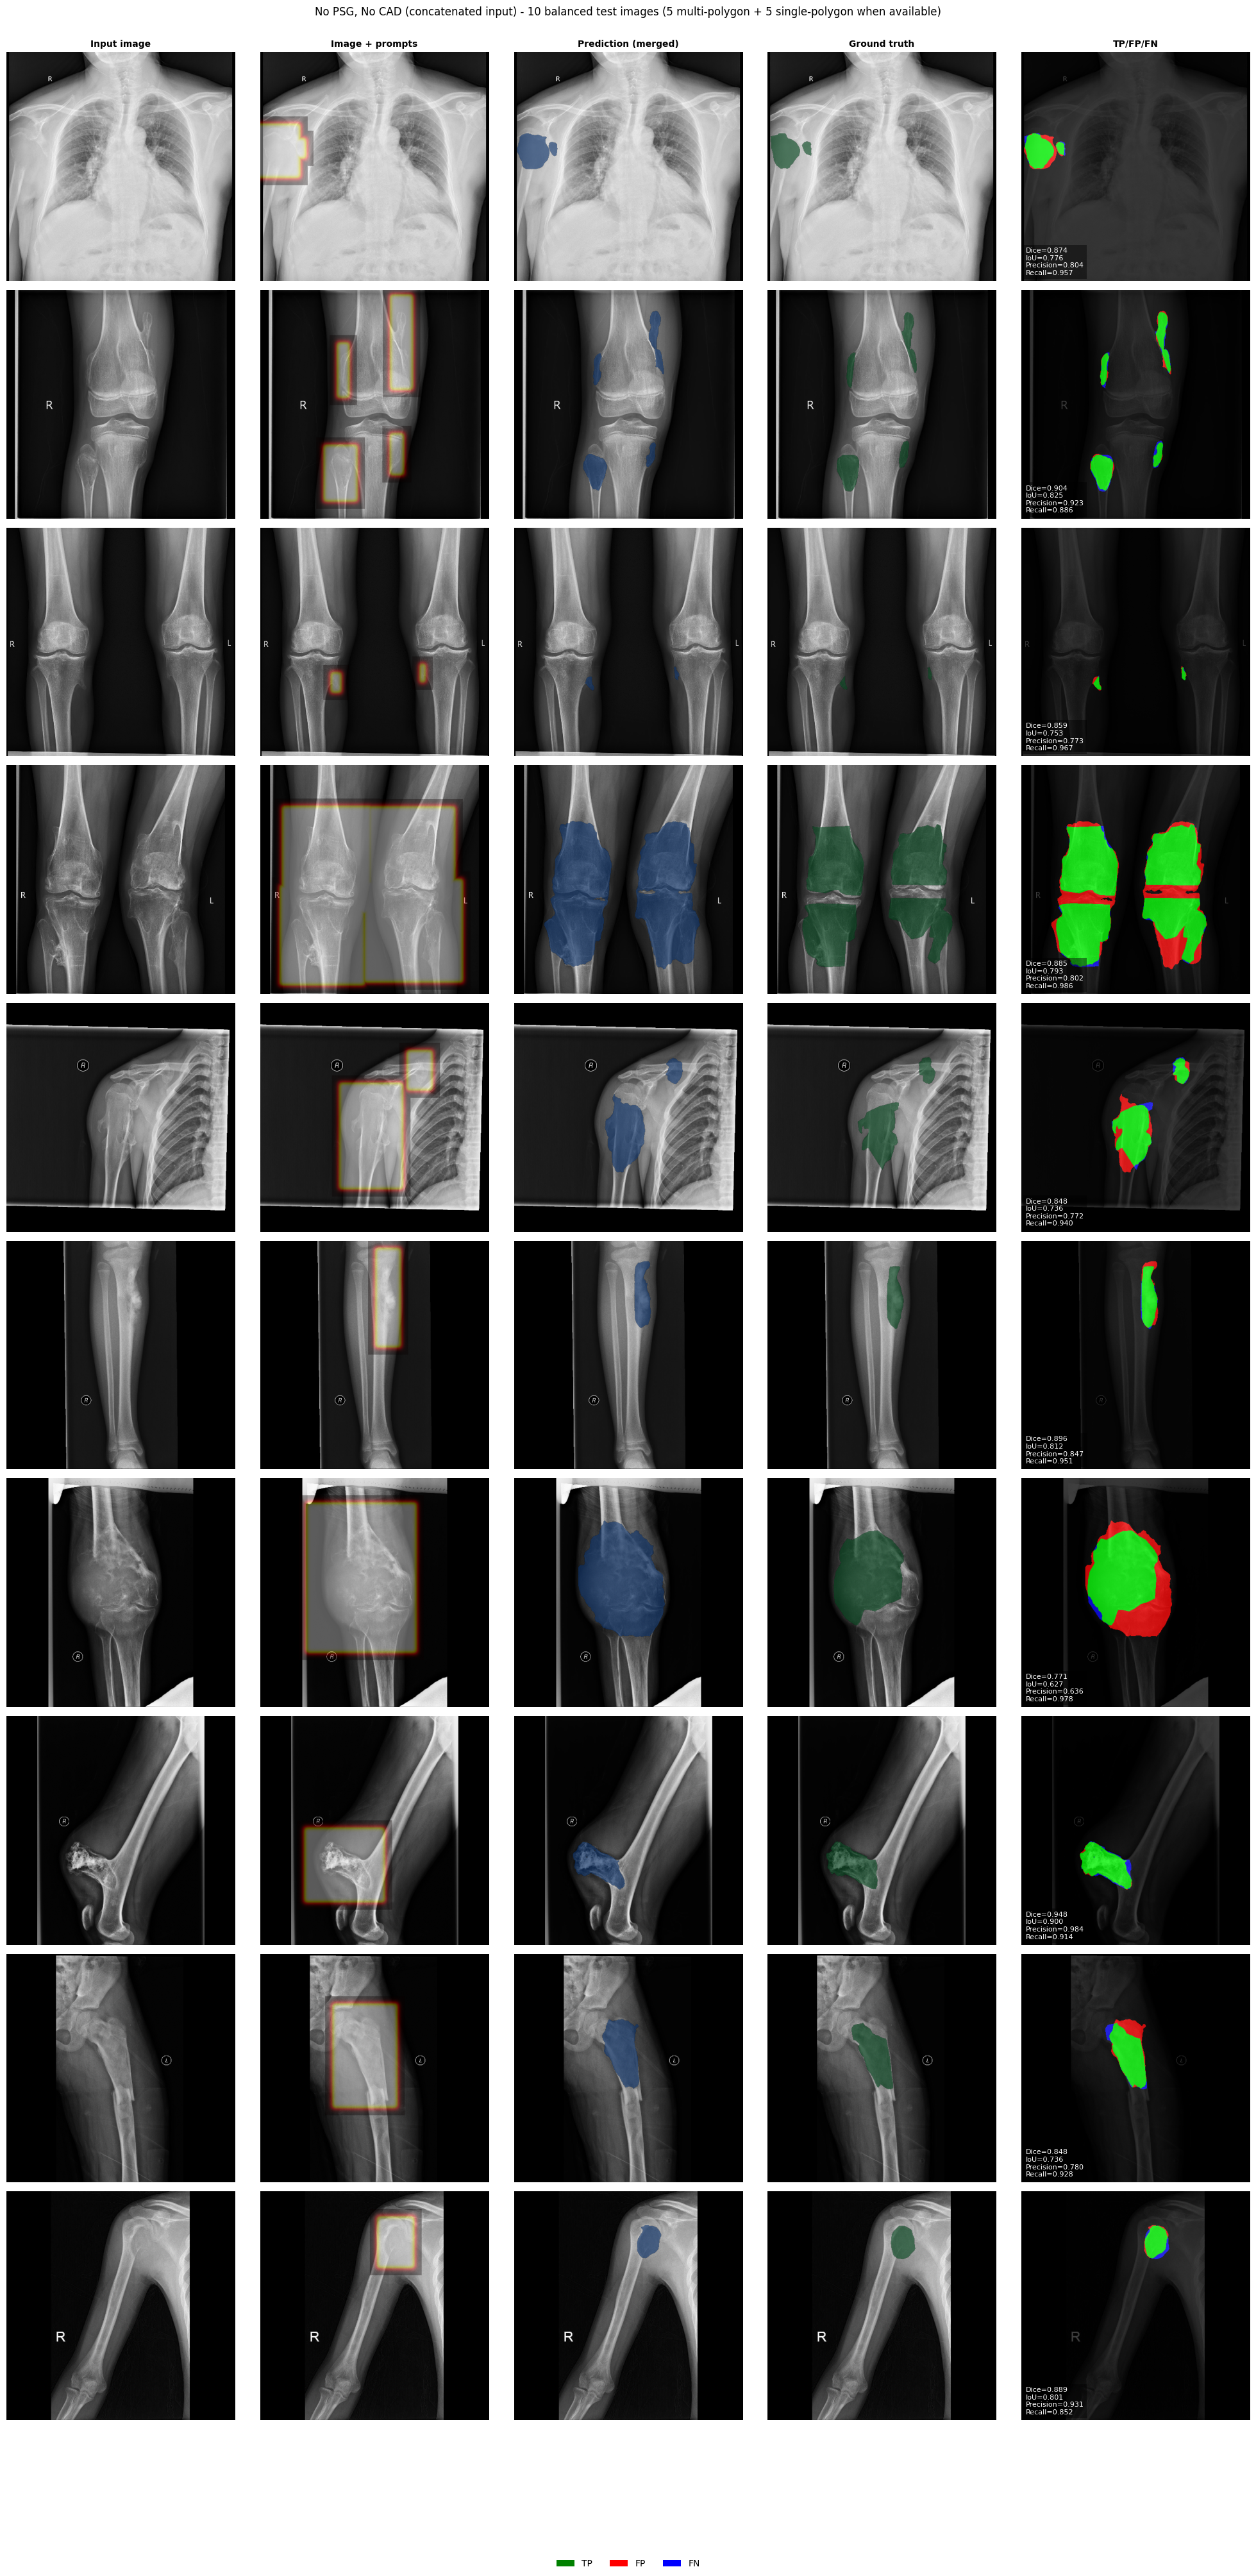

In [5]:
# Balanced qualitative test stems: prefer 5 images with >=2 polygons and 5 images with 1 polygon.
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from IPython.display import display as _ipy_display

assert 'all_image_records' in dir(), '❌ Run the test cell first'
N_MULTI = 5
N_SINGLE = 5

def select_balanced_test_stems(records, n_multi=5, n_single=5):
    multi = [r['img_name'] for r in records if r['n_samples'] >= 2]
    single = [r['img_name'] for r in records if r['n_samples'] == 1]
    chosen = multi[:n_multi] + single[:n_single]
    if len(chosen) < (n_multi + n_single):
        fallback = [r['img_name'] for r in records if r['img_name'] not in chosen]
        chosen.extend(fallback[:(n_multi + n_single - len(chosen))])
    return chosen

BALANCED_TEST_STEMS = select_balanced_test_stems(all_image_records['zoom_out'], N_MULTI, N_SINGLE)
recs = [r for r in all_image_records['zoom_out'] if r['img_name'] in BALANCED_TEST_STEMS]
recs = sorted(recs, key=lambda r: BALANCED_TEST_STEMS.index(r['img_name']))
N_SHOW = len(recs)
print(f'Balanced test stems ({N_SHOW}): {BALANCED_TEST_STEMS}')

fig, axes = plt.subplots(N_SHOW, 5, figsize=(20, 4 * N_SHOW))
if N_SHOW == 1: axes = axes[np.newaxis, :]
fig.suptitle(f'{VARIANT_NAME} - {N_SHOW} balanced test images (5 multi-polygon + 5 single-polygon when available)', fontsize=12, y=1.001)
col_titles = ['Input image', 'Image + prompts', 'Prediction (merged)', 'Ground truth', 'TP/FP/FN']
for ax, ct in zip(axes[0], col_titles): ax.set_title(ct, fontsize=10, fontweight='bold')
for count, rec in enumerate(recs):
    img_np = rec['img'] * 0.5 + 0.5
    gt_np = (rec['gt'] > 0.5).astype(float)
    pred_np = (rec['prob'] > 0.5).astype(float)
    prompt_merged = np.max(np.stack(rec['prompts'], axis=0), axis=0) if len(rec['prompts']) else np.zeros_like(gt_np)
    tp = (pred_np * gt_np).sum(); fp = (pred_np * (1 - gt_np)).sum(); fn = ((1 - pred_np) * gt_np).sum(); eps = 1e-6
    dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
    iou = (tp + eps) / (tp + fp + fn + eps)
    prec = (tp + eps) / (tp + fp + eps)
    rec_ = (tp + eps) / (tp + fn + eps)

    row = axes[count]
    bg = np.stack([img_np] * 3, axis=-1)
    row[0].imshow(img_np, cmap='gray', vmin=0, vmax=1)
    row[0].set_ylabel(f'#{count+1} [{rec["n_samples"]}p]\nDice={dice:.3f}', fontsize=8)
    row[1].imshow(img_np, cmap='gray', vmin=0, vmax=1)
    row[1].imshow(np.where(prompt_merged>0,prompt_merged,np.nan), cmap='hot', alpha=0.35, vmin=0, vmax=1)
    row[2].imshow(bg); row[2].imshow(np.where(pred_np>0,pred_np,np.nan), cmap='Blues', alpha=0.60, vmin=0, vmax=1)
    row[3].imshow(bg); row[3].imshow(np.where(gt_np>0,gt_np,np.nan), cmap='Greens', alpha=0.60, vmin=0, vmax=1)
    overlay = np.zeros((*gt_np.shape, 3), dtype=float)
    overlay[..., 1] = pred_np * gt_np
    overlay[..., 0] = pred_np * (1 - gt_np)
    overlay[..., 2] = (1 - pred_np) * gt_np
    row[4].imshow(bg); row[4].imshow(overlay, alpha=0.75, vmin=0, vmax=1)
    row[4].text(0.02, 0.02, f'Dice={dice:.3f}\nIoU={iou:.3f}\nPrecision={prec:.3f}\nRecall={rec_:.3f}',
                transform=row[4].transAxes, fontsize=8, va='bottom', ha='left',
                bbox=dict(facecolor='black', alpha=0.45, pad=3, edgecolor='none'), color='white')
    for ax in row: ax.axis('off')

handles = [Patch(facecolor='green', label='TP'), Patch(facecolor='red', label='FP'), Patch(facecolor='blue', label='FN')]
fig.legend(handles=handles, loc='lower center', ncol=3, frameon=False)
plt.tight_layout(); plt.subplots_adjust(bottom=0.06)
plt.show()
